# 创建client

In [3]:
from pymilvus import MilvusClient

client = MilvusClient(host="localhost", port=19530)

# 创建 collections

In [22]:
if client.has_collection(collection_name="demo_collection"):
    client.drop_collection(collection_name="demo_collection")
client.create_collection(
    collection_name="demo_collection",
    dimension=768,  # The vectors we will use in this demo has 768 dimensions
)

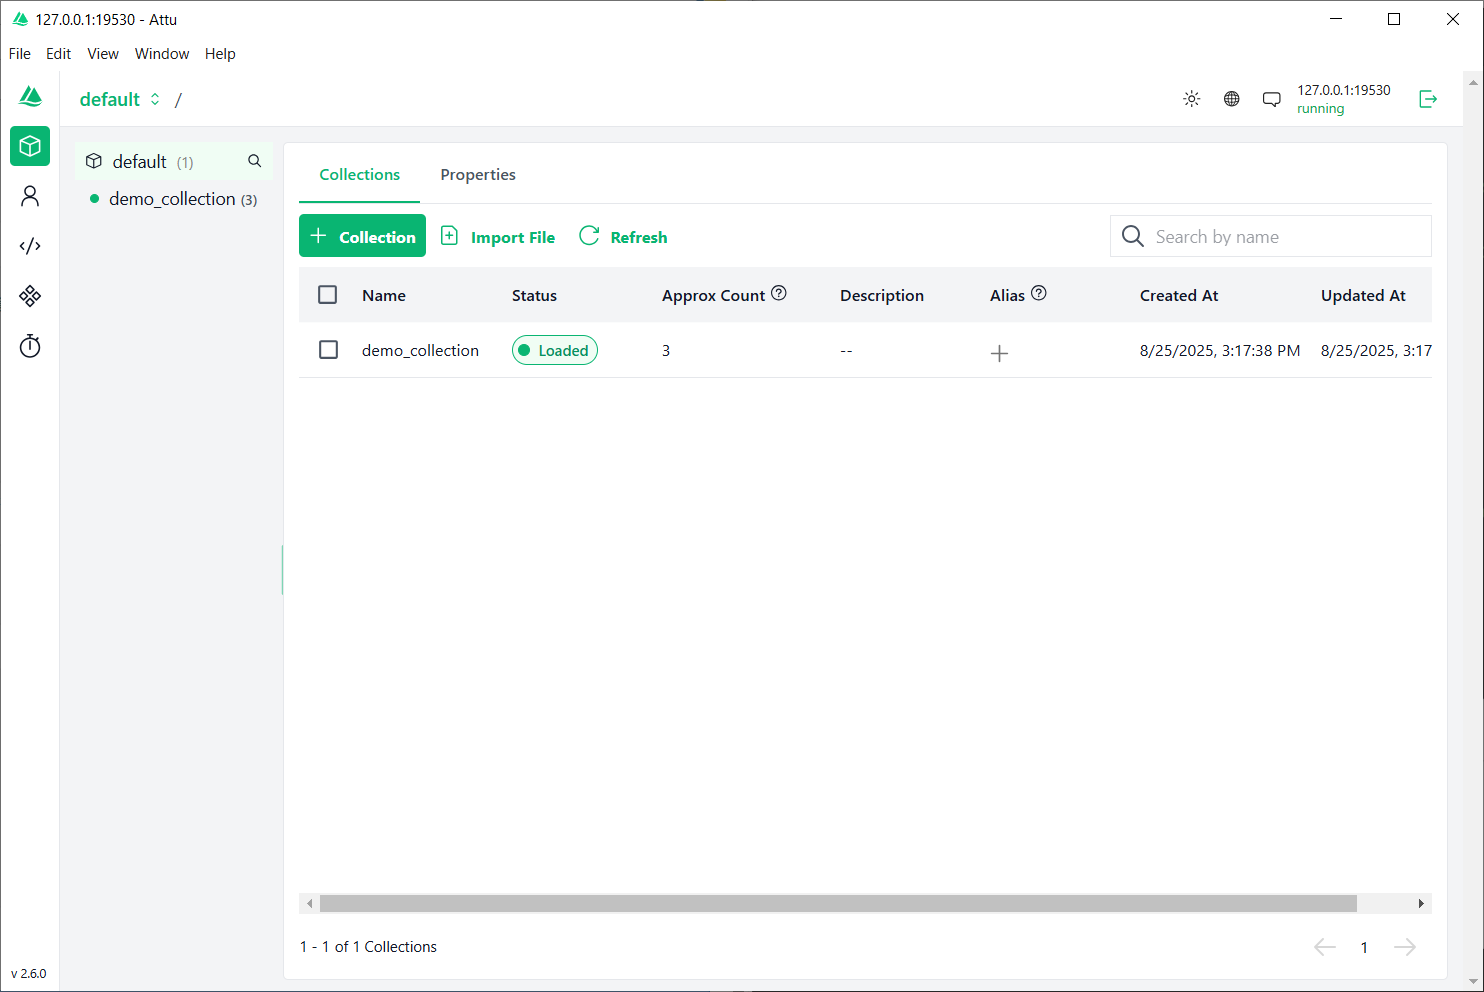

# embedding和schema

In [23]:
# 用默认模型生成向量
from pymilvus import model

# 这句代码会下载一个小的embedding模型 "paraphrase-albert-small-v2" (~50MB).
embedding_fn = model.DefaultEmbeddingFunction()

In [24]:
# 原始文档及其向量化结果
docs = [
    "Artificial intelligence was founded as an academic discipline in 1956.",
    "Alan Turing was the first person to conduct substantial research in AI.",
    "Born in Maida Vale, London, Turing was raised in southern England.",
]

vectors = embedding_fn.encode_documents(docs)
print("Dim:", embedding_fn.dim, vectors[0].shape)  # Dim: 768 (768,)

Dim: 768 (768,)


In [25]:
# 构造要导入到数据库的数据：
# 每个实体都包含ID、向量表示、原始文本以及一个主题标签，稍后我们将使用该标签演示元数据过滤功能。
data = [
    {"id": i, "vector": vectors[i], "text": docs[i], "subject": "history"}
    for i in range(len(vectors))
]

print("Data has", len(data), "entities, each with fields: ", data[0].keys())
print("Vector dim:", len(data[0]["vector"]))

Data has 3 entities, each with fields:  dict_keys(['id', 'vector', 'text', 'subject'])
Vector dim: 768


# 插入数据

In [26]:
res = client.insert(collection_name='demo_collection', data=data)
print(res)

{'insert_count': 3, 'ids': [0, 1, 2]}


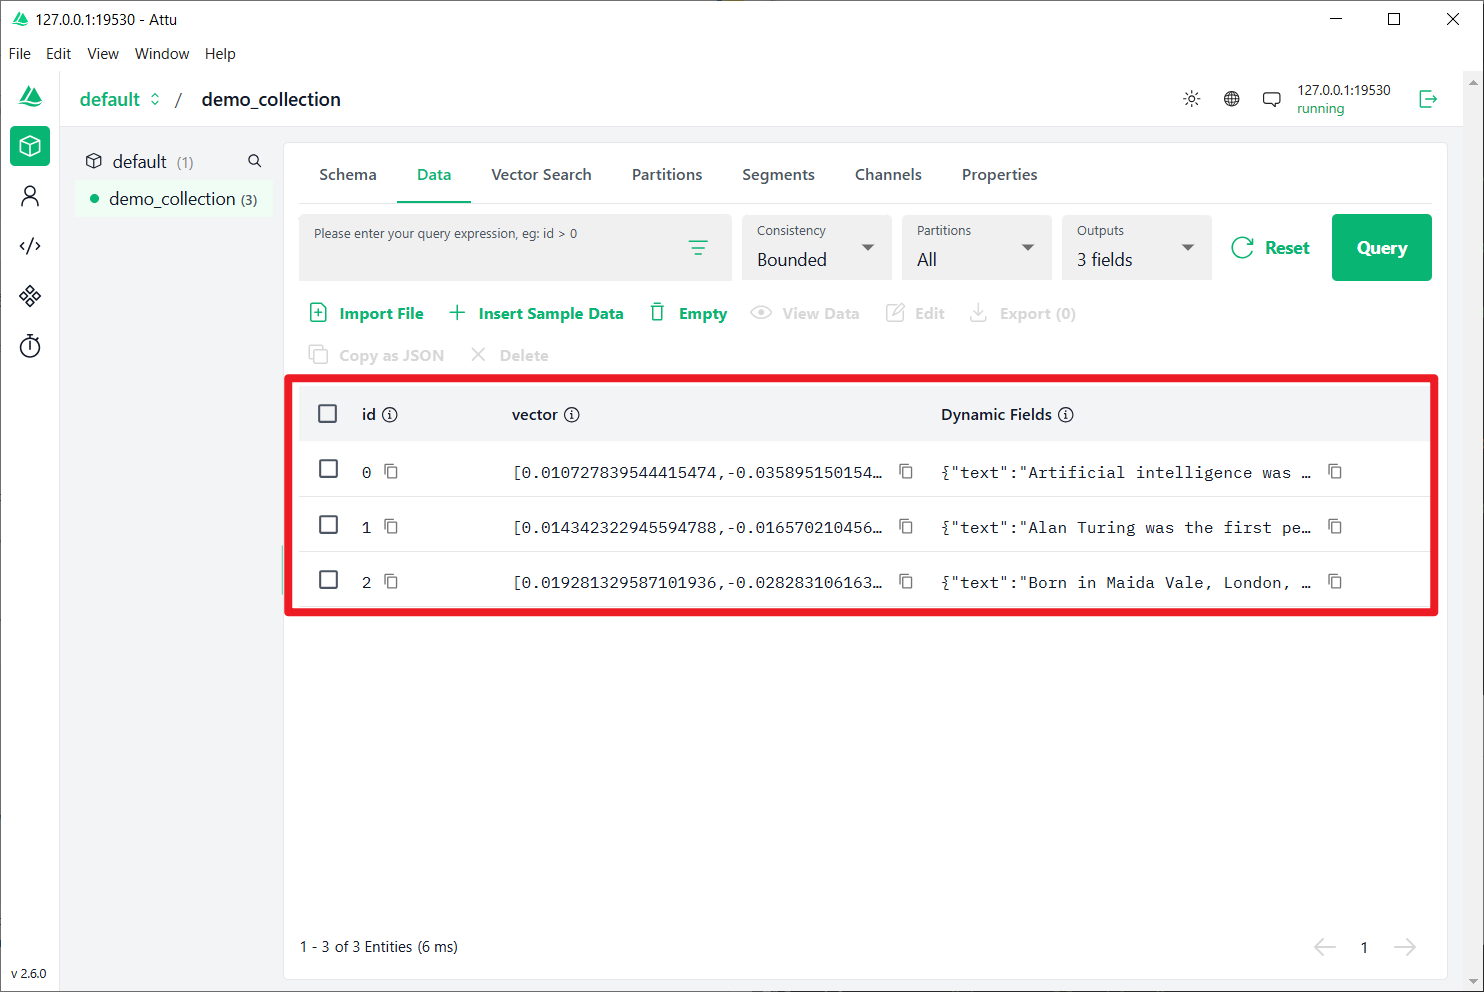

# 向量搜索

In [27]:
query_vectors = embedding_fn.encode_queries(["Who is Alan Turing?"])
res = client.search(
    collection_name="demo_collection",  # target collection
    data=query_vectors,  # query vectors
    limit=2,  # number of returned entities
    output_fields=["text", "subject"],  # specifies fields to be returned
)

print(res)

data: [[{'id': 2, 'distance': 0.5859944820404053, 'entity': {'text': 'Born in Maida Vale, London, Turing was raised in southern England.', 'subject': 'history'}}, {'id': 1, 'distance': 0.5118259191513062, 'entity': {'text': 'Alan Turing was the first person to conduct substantial research in AI.', 'subject': 'history'}}]]


# 过滤表达式搜索

In [28]:
## 示例1：检索标量字段具有特定值的所有实体：
res = client.query(
    collection_name="demo_collection",
    filter="subject == 'history'",
    output_fields=["text", "subject"],
)
print(res)

data: ["{'id': 0, 'text': 'Artificial intelligence was founded as an academic discipline in 1956.', 'subject': 'history'}", "{'id': 1, 'text': 'Alan Turing was the first person to conduct substantial research in AI.', 'subject': 'history'}", "{'id': 2, 'text': 'Born in Maida Vale, London, Turing was raised in southern England.', 'subject': 'history'}"], extra_info: {}


In [33]:
## 示例2：通过主键直接检索实体
res = client.query(
    collection_name="demo_collection",
    ids=[0, 2],
    output_fields=["vector"],
)

print(res[0]['vector'][:10]) #只打印前10维向量

[0.010727839544415474, -0.035895150154829025, 0.018749738112092018, 0.016348766162991524, 0.03651690110564232, 0.0035881721414625645, -0.0004004701040685177, 0.028529386967420578, 0.002274549100548029, 0.0018362500704824924]


# 更新数据
插入或更新数据，如果ID已经存在则更新，否则插入

In [39]:
import numpy as np

docs = [
    "Alan Turing was the first person to conduct substantial research in AI.",
    "Artificial intelligence was founded as an academic discipline in 1956.",
    "Born in Maida Vale, London, Turing was raised in southern England.",
]

# 使用随机向量(假向量)来表示文本
vectors = [[ np.random.uniform(-1, 1) for _ in range(768) ] for _ in range(len(docs)) ]
data = [ {"id": i, "vector": vectors[i], "text": docs[i], "subject": "history"} for i in range(len(vectors)) ]
client.upsert(
    collection_name="demo_collection",
    data=data
)

res = client.query(
    collection_name="demo_collection",
    ids=[0, 2],
    output_fields=["vector"],
)

print(res[0]['vector'][:10]) #只打印前10维向量

[-0.07066074013710022, -0.22824105620384216, 0.8889293074607849, 0.39189064502716064, -0.0480676107108593, -0.22480881214141846, 0.819416880607605, -0.7686644196510315, -0.9732964634895325, -0.2131958305835724]


# 一些Collection操作

In [41]:
# 查看集合信息
schema = client.describe_collection(collection_name='demo_collection')
print(schema)

{'collection_name': 'demo_collection', 'auto_id': False, 'num_shards': 1, 'description': '', 'fields': [{'field_id': 100, 'name': 'id', 'description': '', 'type': <DataType.INT64: 5>, 'params': {}, 'is_primary': True}, {'field_id': 101, 'name': 'vector', 'description': '', 'type': <DataType.FLOAT_VECTOR: 101>, 'params': {'dim': 768}}], 'functions': [], 'aliases': [], 'collection_id': 460352557693173519, 'consistency_level': 2, 'properties': {}, 'num_partitions': 1, 'enable_dynamic_field': True, 'created_timestamp': 460353135974285317, 'update_timestamp': 460353135974285317}


In [42]:
# 列出所有集合
collections = client.list_collections()
print(collections)

['demo_collection']


# 删除实体

In [43]:
## 根据主键删除
res = client.delete(collection_name="demo_collection", ids=[0, 2])
print(res)

{'delete_count': 2}


In [44]:
## 根据过滤表达式搜索
res = client.delete(
    collection_name="demo_collection",
    filter="subject == 'biology'",
)

print(res)

{}


# 删除集合

In [45]:
client.drop_collection(collection_name='demo_collection')